# DSAI 490 — Assignment 1: Representation Learning with Autoencoders

**Dataset:** Medical MNIST  
**Models:** Autoencoder (AE) and Variational Autoencoder (VAE)  
**Sections:**
1. Setup & Configuration
2. Data Loading & Sample Visualization
3. Train AE
4. Train VAE
5. Reconstruction Comparison
6. Latent Space Visualization (PCA)
7. VAE Sample Generation
8. Denoising Robustness Demo

## 1. Setup & Configuration

In [2]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.decomposition import PCA

# Add project root to path so src/ imports work when notebook is opened from notebooks/
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.data_processing import CLASS_NAMES, ensure_dataset, get_dataset, get_labeled_dataset
from src.model import LATENT_DIM, VAE, build_ae, build_vae_components
from src.train import get_strategy, run_training

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

_DEFAULT_DATA_DIR = os.path.join('..', 'data', 'raw', 'medical-mnist')
MODELS_DIR        = os.path.join('..', 'models')
EPOCHS            = 10
BATCH_SIZE        = 64

# Checks for local data; downloads via kagglehub if not found
DATA_DIR = ensure_dataset(_DEFAULT_DATA_DIR)

print(f'TensorFlow {tf.__version__}')
print(f'GPUs available: {tf.config.list_physical_devices("GPU")}')
print(f'Data dir: {DATA_DIR}')

Dataset found at ..\data\raw\medical-mnist
TensorFlow 2.21.0
GPUs available: []
Data dir: ..\data\raw\medical-mnist


## 2. Data Loading & Sample Visualization

In [3]:
train_ds   = get_dataset(DATA_DIR, batch_size=BATCH_SIZE)
labeled_ds = get_labeled_dataset(DATA_DIR, batch_size=256)

num_batches = sum(1 for _ in train_ds)
print(f'Total batches per epoch: {num_batches}  (~{num_batches * BATCH_SIZE:,} images)')

Total batches per epoch: 921  (~58,944 images)


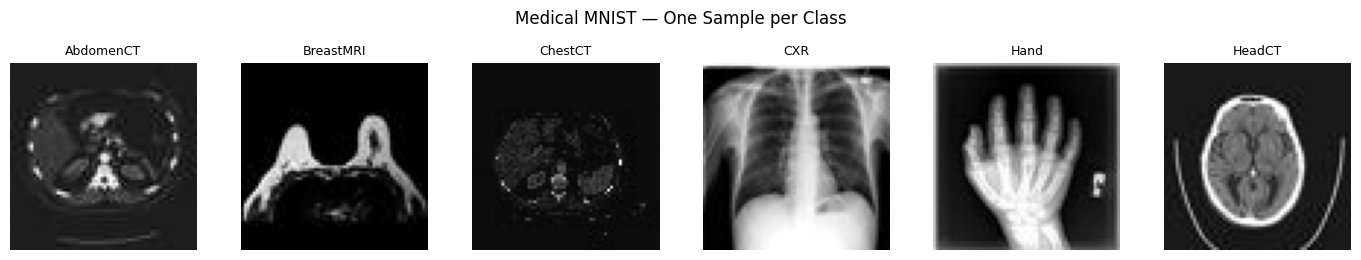

In [4]:
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(14, 2.5))
shown = set()

for batch_imgs, batch_labels in labeled_ds:
    for img, lbl in zip(batch_imgs.numpy(), batch_labels.numpy()):
        if lbl not in shown:
            axes[lbl].imshow(img.squeeze(), cmap='gray')
            axes[lbl].set_title(CLASS_NAMES[lbl], fontsize=9)
            axes[lbl].axis('off')
            shown.add(lbl)
        if len(shown) == len(CLASS_NAMES):
            break
    if len(shown) == len(CLASS_NAMES):
        break

plt.suptitle('Medical MNIST — One Sample per Class', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 3. Train Autoencoder (AE)

In [5]:
ae_history, ae_model = run_training(
    model_type='AE',
    data_dir=DATA_DIR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    models_dir=MODELS_DIR,
)


Using device: /cpu:0

--- Training AE (10 epochs, batch_size=64) ---
Epoch 1/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 255s 275ms/step - loss: 0.0147
Epoch 2/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 201s 218ms/step - loss: 0.0071
Epoch 3/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 125s 135ms/step - loss: 0.0061
Epoch 4/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 107s 116ms/step - loss: 0.0056
Epoch 5/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 118s 128ms/step - loss: 0.0053
Epoch 6/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 117s 127ms/step - loss: 0.0050
Epoch 7/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 164s 177ms/step - loss: 0.0049
Epoch 8/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 163s 176ms/step - loss: 0.0047
Epoch 9/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 128s 139ms/step - loss: 0.0046
Epoch 10/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 129s 140ms/step - loss: 0.0045
Training complete in 1506.5s
Model saved to ..\models\ae_v1.keras


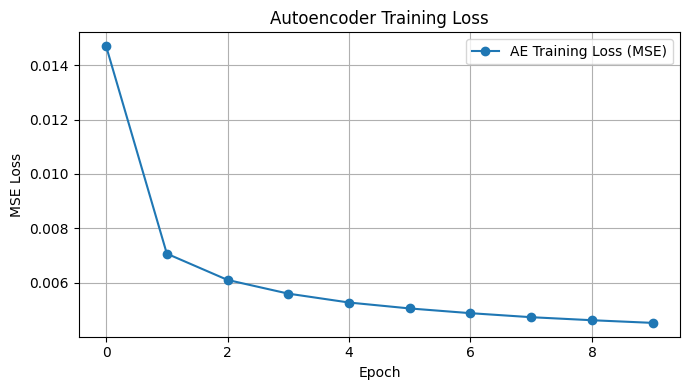

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(ae_history.history['loss'], marker='o', label='AE Training Loss (MSE)')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Train Variational Autoencoder (VAE)

In [7]:
vae_history, vae_model = run_training(
    model_type='VAE',
    data_dir=DATA_DIR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    models_dir=MODELS_DIR,
)

Using device: /cpu:0

--- Training VAE (10 epochs, batch_size=64) ---
Epoch 1/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 272s 291ms/step - kl_loss: 32.5481 - loss: 2074.9653 - reconstruction_loss: 2042.4180
Epoch 2/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 317s 344ms/step - kl_loss: 38.2880 - loss: 1960.4406 - reconstruction_loss: 1922.1517
Epoch 3/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 217s 235ms/step - kl_loss: 38.5753 - loss: 1949.7623 - reconstruction_loss: 1911.1890
Epoch 4/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 132s 143ms/step - kl_loss: 38.4233 - loss: 1944.3148 - reconstruction_loss: 1905.8900
Epoch 5/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 129s 140ms/step - kl_loss: 38.2309 - loss: 1940.8619 - reconstruction_loss: 1902.6298
Epoch 6/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 123s 133ms/step - kl_loss: 37.9788 - loss: 1938.3640 - reconstruction_loss: 1900.3832
Epoch 7/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 118s 128ms/step - kl_loss: 37.7918 - loss: 1936.5422 - reconstruction_loss: 1898.7504
Epoch 8/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 119s 129

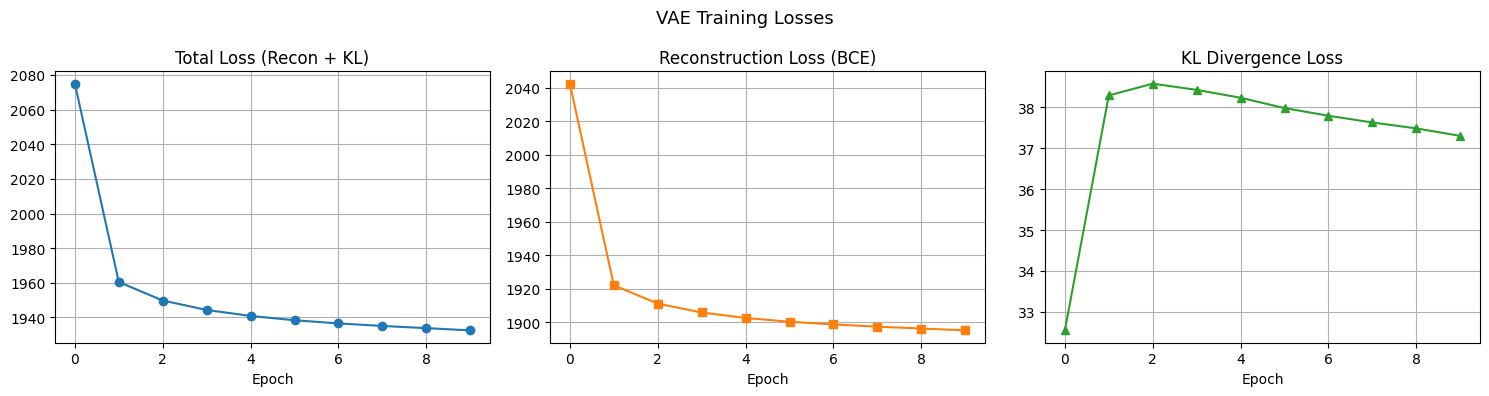

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(vae_history.history['loss'], marker='o', color='tab:blue')
axes[0].set_title('Total Loss (Recon + KL)')
axes[0].set_xlabel('Epoch')
axes[0].grid(True)

axes[1].plot(vae_history.history['reconstruction_loss'], marker='s', color='tab:orange')
axes[1].set_title('Reconstruction Loss (BCE)')
axes[1].set_xlabel('Epoch')
axes[1].grid(True)

axes[2].plot(vae_history.history['kl_loss'], marker='^', color='tab:green')
axes[2].set_title('KL Divergence Loss')
axes[2].set_xlabel('Epoch')
axes[2].grid(True)

plt.suptitle('VAE Training Losses', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Reconstruction Comparison

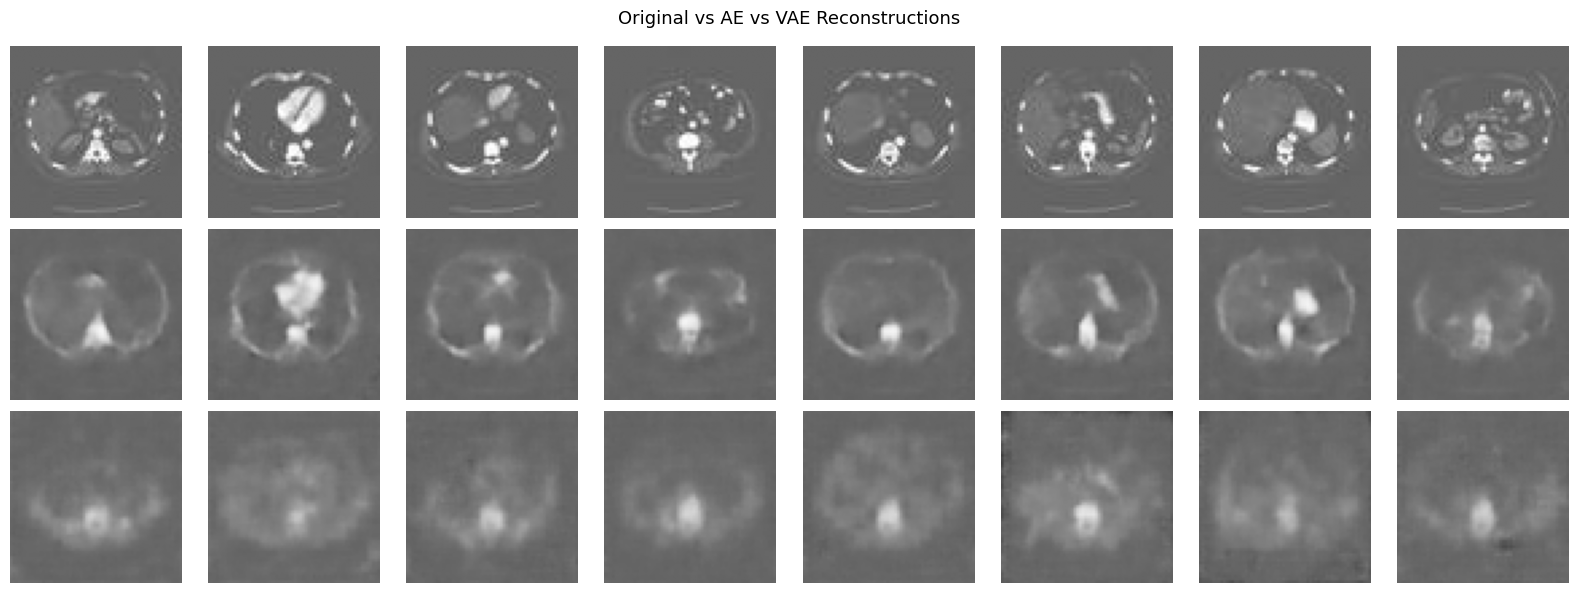

AE  MSE on sample batch: 0.00342
VAE MSE on sample batch: 0.00639


In [9]:
NUM_IMAGES = 8

for batch, _ in get_dataset(DATA_DIR, batch_size=NUM_IMAGES, shuffle=False).take(1):
    originals = batch.numpy()

ae_recons  = ae_model.predict(originals, verbose=0)
vae_recons = vae_model.predict(originals, verbose=0)

fig, axes = plt.subplots(3, NUM_IMAGES, figsize=(NUM_IMAGES * 2, 6))
row_labels = ['Original', 'AE Reconstruction', 'VAE Reconstruction']

for col in range(NUM_IMAGES):
    for row, imgs in enumerate([originals, ae_recons, vae_recons]):
        axes[row, col].imshow(imgs[col].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=10, rotation=90, labelpad=50)

plt.suptitle('Original vs AE vs VAE Reconstructions', fontsize=13)
plt.tight_layout()
plt.show()

ae_mse  = float(np.mean((originals - ae_recons) ** 2))
vae_mse = float(np.mean((originals - vae_recons) ** 2))
print(f'AE  MSE on sample batch: {ae_mse:.5f}')
print(f'VAE MSE on sample batch: {vae_mse:.5f}')

## 6. Latent Space Visualization (PCA)

In [10]:
MAX_SAMPLES = 2000
ae_latents, vae_latents, all_labels = [], [], []

ae_encoder = ae_model.get_layer('ae_encoder')

collected = 0
for imgs, labels in labeled_ds:
    n    = imgs.shape[0]
    take = min(n, MAX_SAMPLES - collected)
    imgs_slice   = imgs[:take]
    labels_slice = labels[:take].numpy()

    ae_z             = ae_encoder(imgs_slice, training=False).numpy()
    vae_z_mean, _, _ = vae_model.encoder(imgs_slice, training=False)
    vae_z_mean       = vae_z_mean.numpy()

    ae_latents.append(ae_z)
    vae_latents.append(vae_z_mean)
    all_labels.append(labels_slice)

    collected += take
    if collected >= MAX_SAMPLES:
        break

ae_latents  = np.concatenate(ae_latents)
vae_latents = np.concatenate(vae_latents)
all_labels  = np.concatenate(all_labels)
print(f'Collected {len(all_labels)} samples for visualization')

Collected 2000 samples for visualization


In [11]:
pca = PCA(n_components=2, random_state=42)
ae_pca  = pca.fit_transform(ae_latents)
vae_pca = pca.fit_transform(vae_latents)

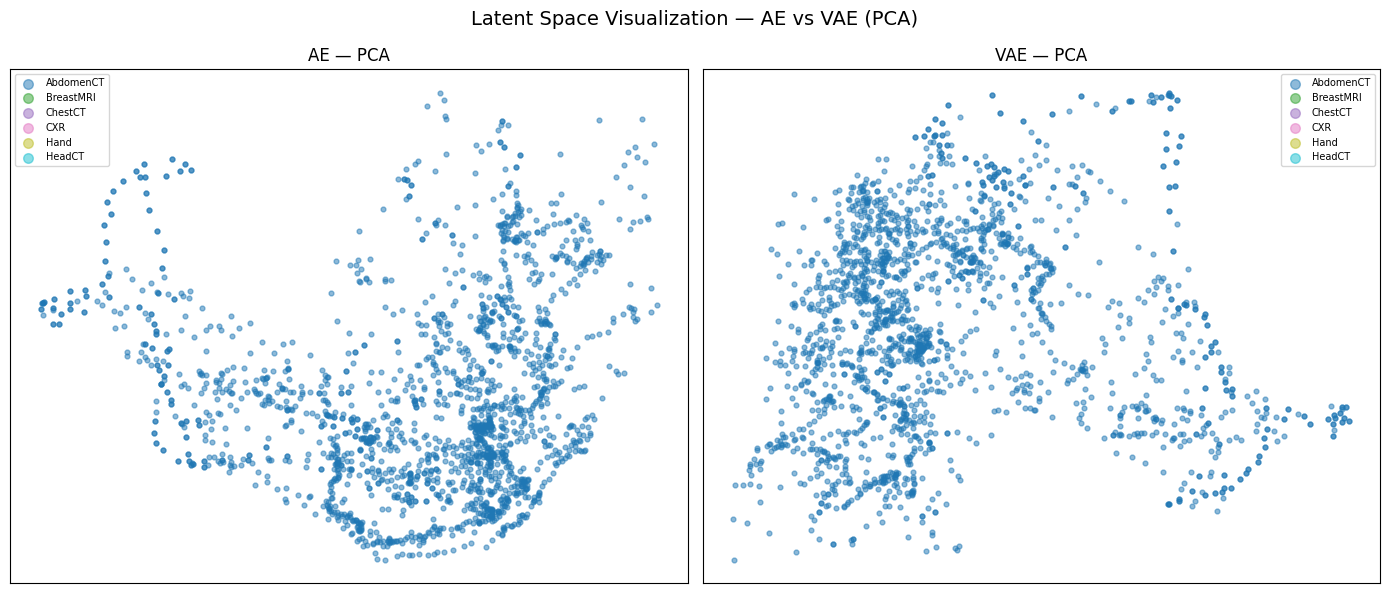

In [12]:
COLORS = plt.cm.tab10(np.linspace(0, 1, len(CLASS_NAMES)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
titles = [
    ('AE — PCA',  ae_pca),
    ('VAE — PCA', vae_pca),
]

for ax, (title, coords) in zip(axes, titles):
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        mask = all_labels == cls_idx
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=[COLORS[cls_idx]], label=cls_name, alpha=0.5, s=12)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=7, markerscale=2)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Latent Space Visualization — AE vs VAE (PCA)', fontsize=14)
plt.tight_layout()
plt.show()

## 7. VAE Sample Generation

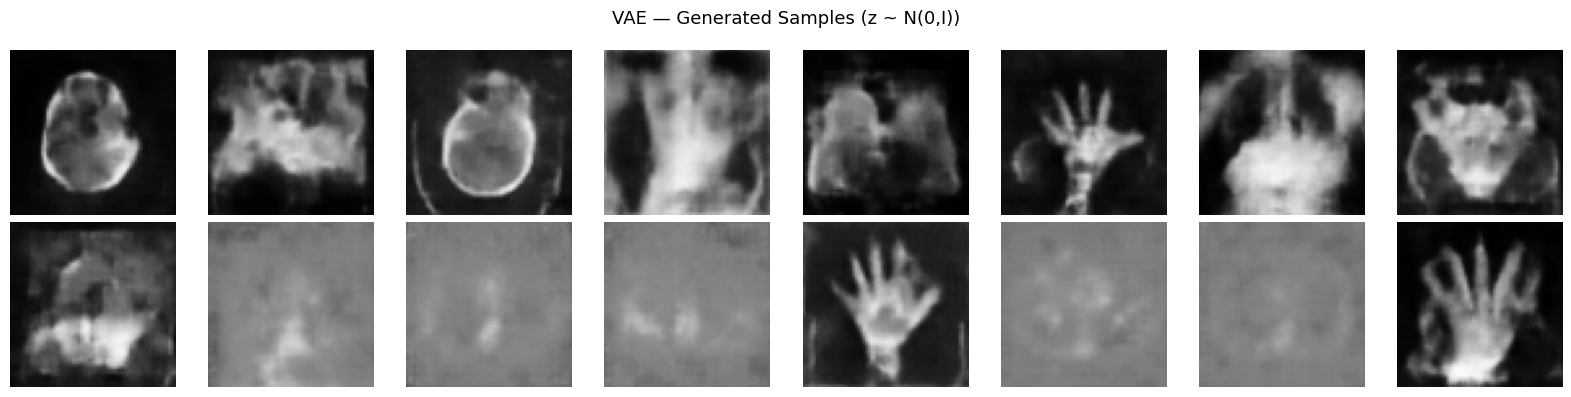

In [13]:
NUM_GENERATED = 16
GRID_COLS     = 8

# Sample z ~ N(0, I) and decode to image space
z_samples = tf.random.normal(shape=(NUM_GENERATED, LATENT_DIM))
generated = vae_model.decoder(z_samples, training=False).numpy()

fig, axes = plt.subplots(NUM_GENERATED // GRID_COLS, GRID_COLS,
                         figsize=(GRID_COLS * 2, (NUM_GENERATED // GRID_COLS) * 2))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')

plt.suptitle('VAE — Generated Samples (z ~ N(0,I))', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Denoising Robustness Demo

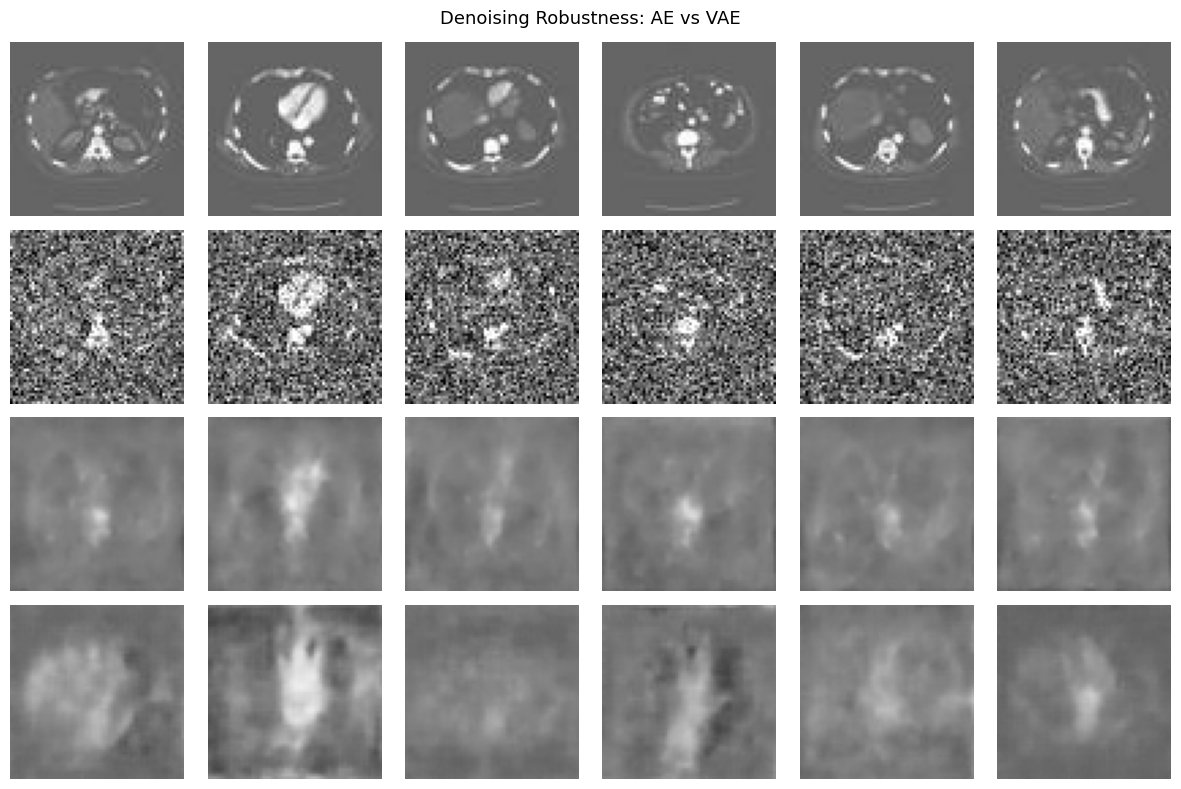

Noisy input MSE vs clean : 0.03765
AE  denoised MSE vs clean: 0.01024
VAE denoised MSE vs clean: 0.01236


In [14]:
NOISE_STD   = 0.2
NUM_DENOISE = 6

for clean, _ in get_dataset(DATA_DIR, batch_size=NUM_DENOISE, shuffle=False).take(1):
    clean_np = clean.numpy()

noisy_np = np.clip(clean_np + np.random.normal(0, NOISE_STD, clean_np.shape), 0, 1)

noisy_t      = tf.constant(noisy_np, dtype=tf.float32)
ae_denoised  = ae_model(noisy_t, training=False).numpy()
vae_denoised = vae_model(noisy_t, training=False).numpy()

fig, axes = plt.subplots(4, NUM_DENOISE, figsize=(NUM_DENOISE * 2, 8))
row_labels = ['Clean', f'Noisy (σ={NOISE_STD})', 'AE Denoised', 'VAE Denoised']

for col in range(NUM_DENOISE):
    for row, imgs in enumerate([clean_np, noisy_np, ae_denoised, vae_denoised]):
        axes[row, col].imshow(imgs[col].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=10, rotation=90, labelpad=50)

plt.suptitle('Denoising Robustness: AE vs VAE', fontsize=13)
plt.tight_layout()
plt.show()

noisy_mse       = float(np.mean((clean_np - noisy_np) ** 2))
ae_denoise_mse  = float(np.mean((clean_np - ae_denoised) ** 2))
vae_denoise_mse = float(np.mean((clean_np - vae_denoised) ** 2))
print(f'Noisy input MSE vs clean : {noisy_mse:.5f}')
print(f'AE  denoised MSE vs clean: {ae_denoise_mse:.5f}')
print(f'VAE denoised MSE vs clean: {vae_denoise_mse:.5f}')